In [25]:
!pip install torch torchvision matplotlib

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np

# set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [27]:
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5, hidden_sizes=None):
        super(AblationMLP, self).__init__()
        # Default hidden sizes if not specified
        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]
        
        # flatten 32x32x3 -> 3072
        self.flatten = nn.Flatten()
        
        # manual linear layers: 3072 -> h1 -> h2 -> h3 -> 10
        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        self.fc4 = nn.Linear(hidden_sizes[2], 10)
        self.softmax = nn.Softmax(dim=1)
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
    
    def forward(self, x):
        x = self.flatten(x)
        
        # layer 1
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)
        
        # layer 2
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)
        
        # layer 3
        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)
        
        # output
        x = self.fc4(x)
        return x

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use fixed seed for reproducible split
torch.manual_seed(42)
reduce_train_size = int(0.1 * len(full_train_dataset))
full_train_reduced, _ = torch.utils.data.random_split(full_train_dataset, [reduce_train_size, len(full_train_dataset) - reduce_train_size])

# Create validation split with fixed seed (10% of reduced training data)
torch.manual_seed(42)
train_size = int(0.9 * len(full_train_reduced))
val_size = len(full_train_reduced) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_reduced, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training set size: {len(train_dataset)} (fixed split, 10% of CIFAR-10)")
print(f"Validation set size: {len(val_dataset)} (fixed split, 10% of reduced)")
print(f"Test set size: {len(test_dataset)} (fixed split)")

Training set size: 4500 (fixed split, 10% of CIFAR-10)
Validation set size: 500 (fixed split, 10% of reduced)
Test set size: 10000 (fixed split)


In [29]:
# setup device and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
max_epochs = 20 # you can modify this according to hwat gpu you have 

# initialize model with increased complexity [8192, 4096, 2048] for maximum overfitting
model = AblationMLP(use_dropout=False, use_batchnorm=False, hidden_sizes=[8192, 4096, 2048]).to(device)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print(f"Device: {device}")
print(f"Learning Rate: {learning_rate}")
print(f"Max Epochs: {max_epochs}")
print(f"Model: Ultra High Capacity [8192, 4096, 2048] with Fixed Splits (No Regularization)")

Device: cpu
Learning Rate: 0.01
Max Epochs: 20
Model: Ultra High Capacity [8192, 4096, 2048] with Fixed Splits (No Regularization)


In [30]:
def evaluate(model, dataloader, device):
    """compute accuracy on a dataloader"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    model.train()
    return accuracy

def compute_loss(model, dataloader, loss_fn, device):
    """compute loss on a dataloader"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
    
    model.train()
    return total_loss / len(dataloader)

def train_epoch(model, train_loader, optimizer, loss_fn, device):
    """train for one epoch and return loss"""
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

In [31]:
# train the model for 20 epochs and track metrics
train_losses = []
val_losses = []
test_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []

for epoch in range(max_epochs):
    # train
    loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
    train_losses.append(loss)
    
    # evaluate
    train_acc = evaluate(model, train_loader, device)
    val_loss = compute_loss(model, val_loader, loss_fn, device)
    val_acc = evaluate(model, val_loader, device)
    test_loss = compute_loss(model, test_loader, loss_fn, device)
    test_acc = evaluate(model, test_loader, device)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    
    print(f"Epoch {epoch+1}/{max_epochs} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("\nTraining completed!")
print(f"Final Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Generalization Gap (Train-Val): {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print(f"Generalization Gap (Train-Test): {train_accuracies[-1] - test_accuracies[-1]:.2f}%")

Epoch 1/20 | Train Loss: 2.2625 | Val Loss: 2.2238 | Test Loss: 2.2171 | Train Acc: 25.16% | Val Acc: 22.40% | Test Acc: 24.37%
Epoch 2/20 | Train Loss: 2.1738 | Val Loss: 2.1488 | Test Loss: 2.1385 | Train Acc: 26.80% | Val Acc: 23.20% | Test Acc: 25.81%
Epoch 3/20 | Train Loss: 2.0930 | Val Loss: 2.0753 | Test Loss: 2.0649 | Train Acc: 30.91% | Val Acc: 25.20% | Test Acc: 28.55%
Epoch 4/20 | Train Loss: 2.0229 | Val Loss: 2.0169 | Test Loss: 2.0044 | Train Acc: 32.49% | Val Acc: 26.80% | Test Acc: 30.64%
Epoch 5/20 | Train Loss: 1.9631 | Val Loss: 1.9719 | Test Loss: 1.9609 | Train Acc: 33.53% | Val Acc: 28.60% | Test Acc: 30.89%
Epoch 6/20 | Train Loss: 1.9197 | Val Loss: 1.9378 | Test Loss: 1.9371 | Train Acc: 34.02% | Val Acc: 28.20% | Test Acc: 30.72%
Epoch 7/20 | Train Loss: 1.8747 | Val Loss: 1.9045 | Test Loss: 1.8821 | Train Acc: 37.40% | Val Acc: 30.60% | Test Acc: 33.98%
Epoch 8/20 | Train Loss: 1.8263 | Val Loss: 1.8593 | Test Loss: 1.8490 | Train Acc: 38.89% | Val Acc: 31

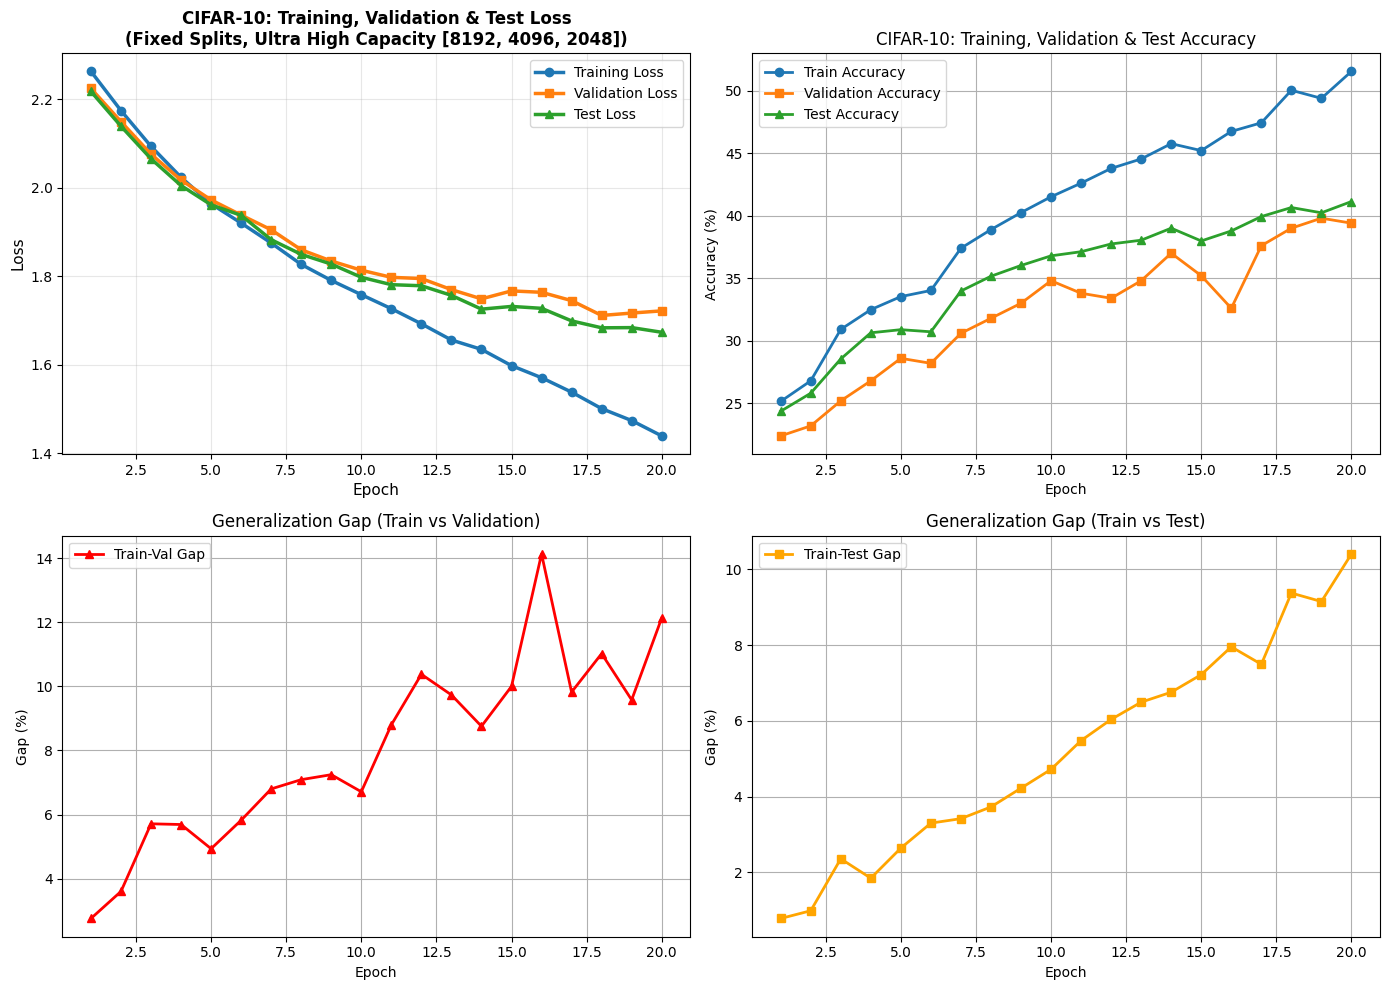

In [32]:
# visualize generalization gap with test loss
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# plot loss curves with training, validation, and test loss
ax1.plot(range(1, max_epochs+1), train_losses, label='Training Loss', marker='o', linewidth=2.5, markersize=6, color='#1f77b4')
ax1.plot(range(1, max_epochs+1), val_losses, label='Validation Loss', marker='s', linewidth=2.5, markersize=6, color='#ff7f0e')
ax1.plot(range(1, max_epochs+1), test_losses, label='Test Loss', marker='^', linewidth=2.5, markersize=6, color='#2ca02c')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('CIFAR-10: Training, Validation & Test Loss\n(Fixed Splits, Ultra High Capacity [8192, 4096, 2048])', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# plot accuracy curves
ax2.plot(range(1, max_epochs+1), train_accuracies, label='Train Accuracy', marker='o', linewidth=2)
ax2.plot(range(1, max_epochs+1), val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
ax2.plot(range(1, max_epochs+1), test_accuracies, label='Test Accuracy', marker='^', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('CIFAR-10: Training, Validation & Test Accuracy')
ax2.legend()
ax2.grid(True)

# plot generalization gap (train vs validation)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(max_epochs)]
ax3.plot(range(1, max_epochs+1), gap, label='Train-Val Gap', marker='^', color='red', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gap (%)')
ax3.set_title('Generalization Gap (Train vs Validation)')
ax3.legend()
ax3.grid(True)

# plot train vs test gap
test_gap = [train_accuracies[i] - test_accuracies[i] for i in range(max_epochs)]
ax4.plot(range(1, max_epochs+1), test_gap, label='Train-Test Gap', marker='s', color='orange', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Gap (%)')
ax4.set_title('Generalization Gap (Train vs Test)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

This is when no regularization ,early stopping,and noise is applied 
